In [1]:
# --- 3.1 Read FITS Files ---
#2
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
import os

#3
base_path = r'C:\Users\eilee\python_decal_sp26\course_assignments\homework10'

fits_files = [f'M13_000{i}.fits' for i in range(1, 6)]
all_data = []

for filename in fits_files:
    full_path = os.path.join(base_path, filename)
    with fits.open(full_path) as hdul:
        all_data.append(hdul[0].data)

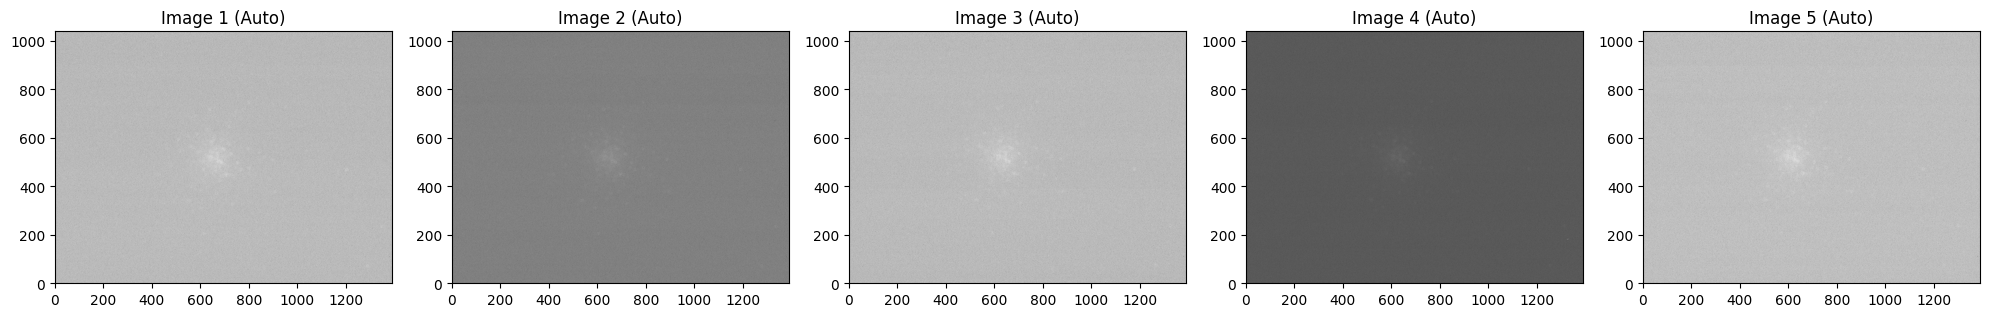

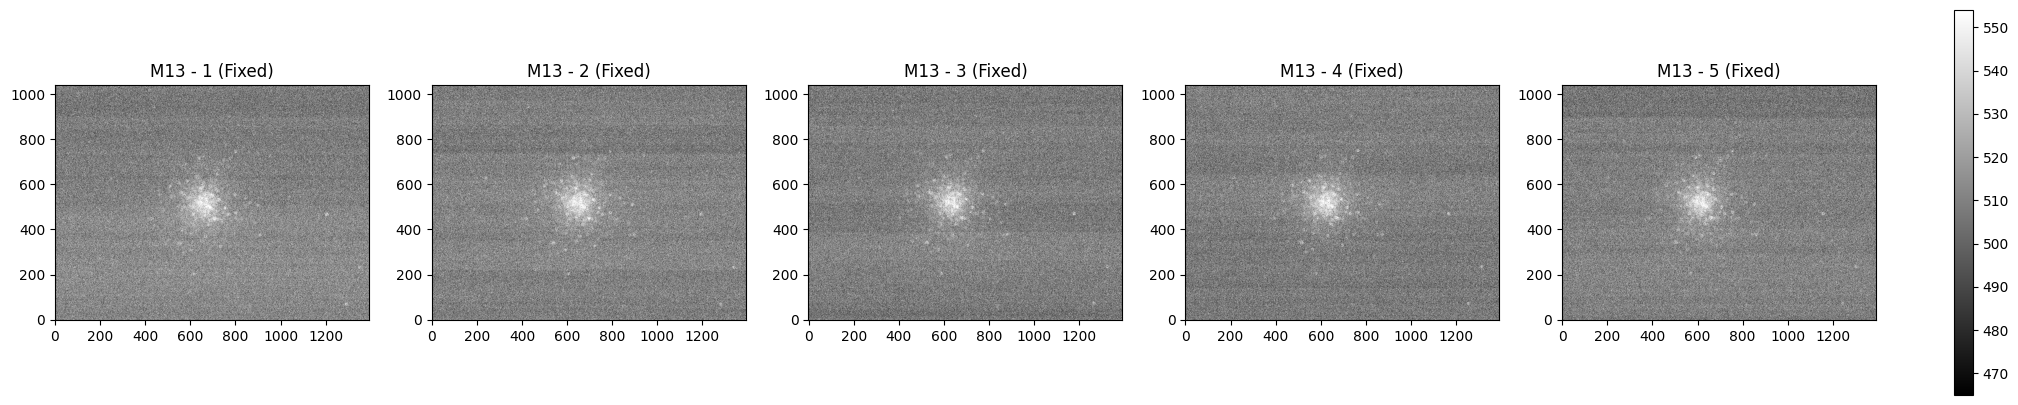

In the second set of plots, the brightness and contrast are consistent across all images. Unlike the first set, which auto-scaled each image individually, the shared scale shows the true relative brightness and background noise of each exposure.


In [2]:
# --- 3.2 Plot Images ---
#1
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i in range(5):
    axes[i].imshow(all_data[i], origin="lower", cmap='gray')
    axes[i].set_title(f"Image {i+1} (Auto)")

plt.tight_layout()
plt.show()

#2
vmin = np.percentile(all_data[0], 5)
vmax = np.percentile(all_data[0], 95)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i in range(5):
    im = axes[i].imshow(all_data[i], origin="lower", cmap='gray', vmin=vmin, vmax=vmax)
    axes[i].set_title(f"M13 - {i+1} (Fixed)")
    
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)

plt.show()

print("In the second set of plots, the brightness and contrast are consistent across all images. Unlike the first set, which auto-scaled each image individually, the shared scale shows the true relative brightness and background noise of each exposure.")

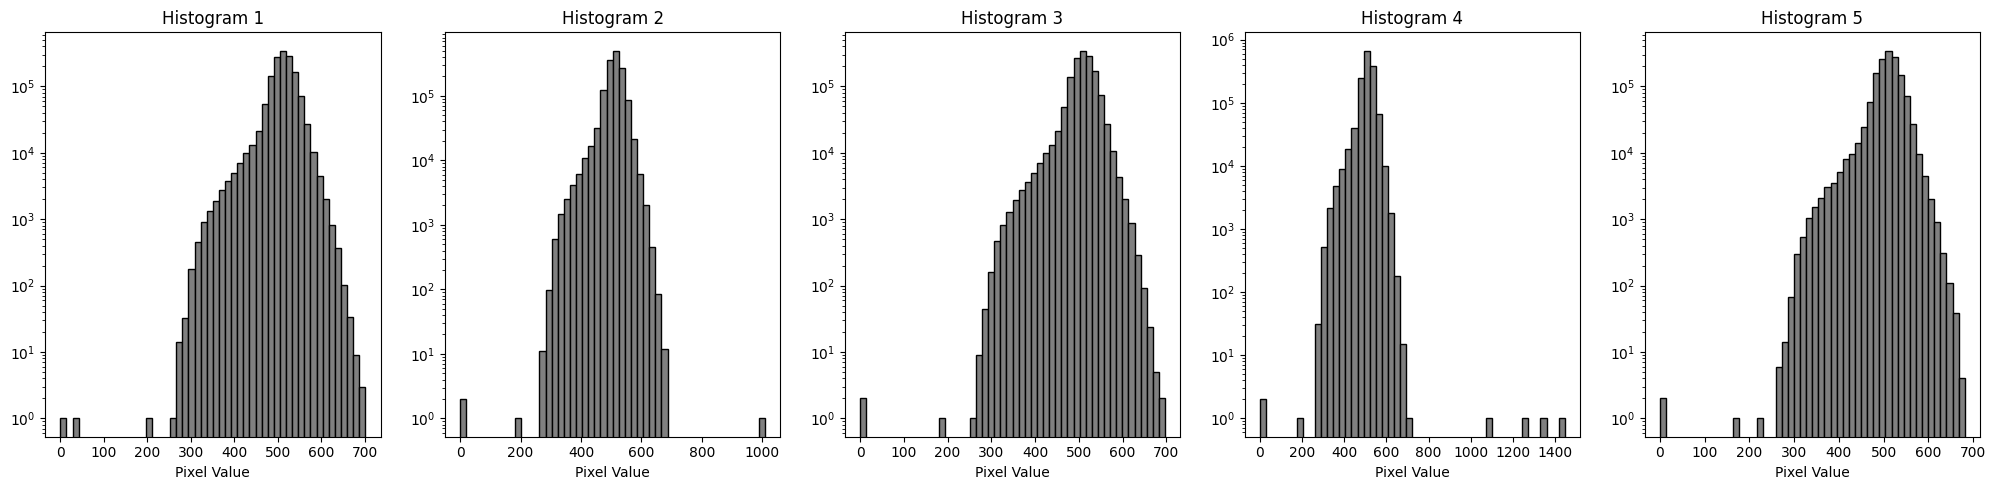

(a) x-axis: Pixel Intensity (brightness values).
y-axis: Frequency (number of pixels with that specific intensity).

(b) bins=50 means the range of pixel values is divided into 50 equal-sized intervals to show the distribution.

(c) Most of the data is centered around the lower end of the x-axis (approximately 3400 to 3600). This represents the dark background of the sky.

(d) Ignoring outliers, the data is very tightly clustered, with most pixels falling within a range of about 200–300 units.

(e)
Image 1:
  Mean: 510.47
  Median: 512.00
Image 2:
  Mean: 509.75
  Median: 511.00
Image 3:
  Mean: 508.05
  Median: 510.00
Image 4:
  Mean: 507.91
  Median: 509.00
Image 5:
  Mean: 508.79
  Median: 510.00


In [3]:
# --- 3.3 Plot Histograms ---
#1
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i in range(5):
    axes[i].hist(all_data[i].ravel(), bins=50, color='gray', edgecolor='black')
    axes[i].set_title(f"Histogram {i+1}")
    axes[i].set_xlabel("Pixel Value")
    axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

#2
print("(a) x-axis: Pixel Intensity (brightness values).\ny-axis: Frequency (number of pixels with that specific intensity).")
print("\n(b) bins=50 means the range of pixel values is divided into 50 equal-sized intervals to show the distribution.\n")
print("(c) Most of the data is centered around the lower end of the x-axis (approximately 3400 to 3600). This represents the dark background of the sky.\n")
print("(d) Ignoring outliers, the data is very tightly clustered, with most pixels falling within a range of about 200–300 units.\n")
print("(e)")
for i, data in enumerate(all_data):
    print(f"Image {i+1}:")
    print(f"  Mean: {np.mean(data):.2f}")
    print(f"  Median: {np.median(data):.2f}")

The new median pixel intensity is: 510.00


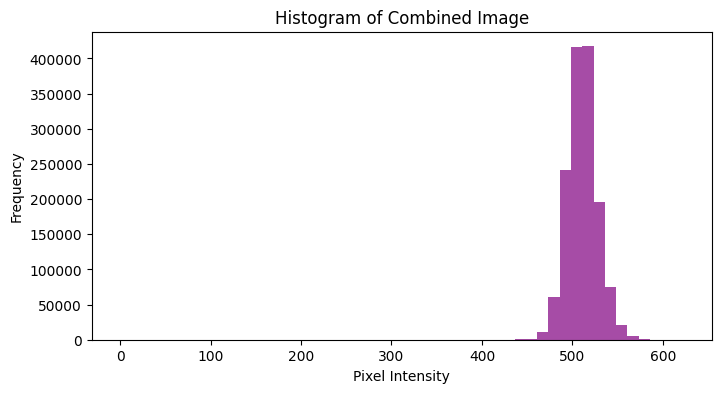

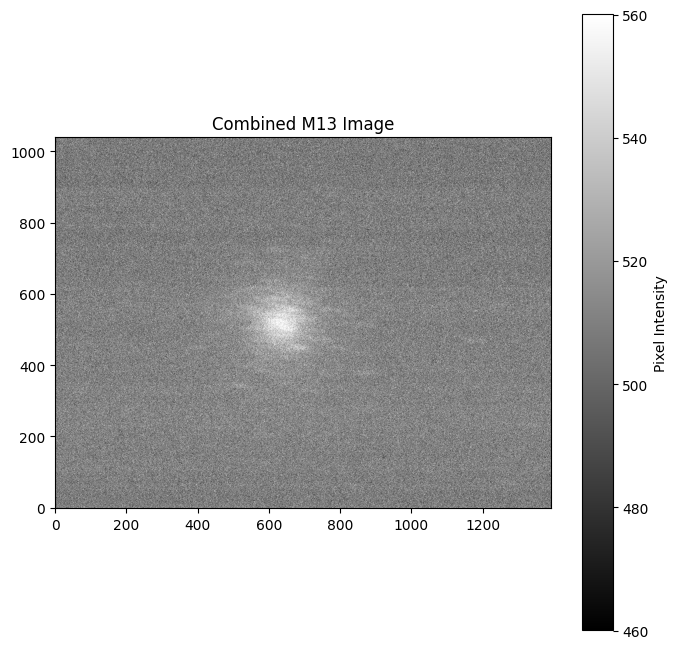

The combined image is significantly cleaner with reduced noise and better contrast.


In [4]:
# --- 3.4 Combine and Normalize Images ---
#1
combined_image = np.median(all_data, axis=0)
new_median = np.median(combined_image)
print(f"The new median pixel intensity is: {new_median:.2f}")

#2
plt.figure(figsize=(8, 4))
plt.hist(combined_image.ravel(), bins=50, color='purple', alpha=0.7)
plt.title("Histogram of Combined Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

#3
vmin = new_median - 50
vmax = new_median + 50

plt.figure(figsize=(8, 8))
plt.imshow(combined_image, origin="lower", cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Combined M13 Image")
plt.colorbar(label='Pixel Intensity')
plt.show()

#4
print("The combined image is significantly cleaner with reduced noise and better contrast.")

#5
fits.writeto("combined.fits", combined_image, overwrite=True)